# Importación de librerías:
## pandas: importación y manipulación de datos
## numpy: cálculos numéricos y operaciones con arrays multidimensionales
## matplotlib.pyplot: visualización de gráficos
## seaborn: visualización estadística avanzada basada en matplotlib
## torch: creación y entrenamiento de redes neuronales
## train_test_split: divide los datos en entrenamiento y validación
## StandardScaler: normalización de características numéricas
## accuracy_score, f1_score, confusion_matrix, classification_report: métricas de evaluación
## RobertaTokenizer, RobertaModel: tokenización y modelo RoBERTa preentrenado (para extracción de características)

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from transformers import RobertaModel, RobertaTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy
import pandas as pd
from tqdm import tqdm

In [19]:
data = pd.read_csv("reviews_22052025_2400.csv")

In [20]:
data.columns

Index(['review_id', 'user_id', 'business_id', 'review_count_user', 'text',
       'average_stars_user', 'yelping_days', 'useful', 'funny', 'cool', 'fans',
       'Cluster'],
      dtype='object')

In [21]:
data.rename(columns={'classification': 'Cluster'}, inplace=True)

# Se convierte Genuine en 1 y Fake en 0

In [22]:
data['Cluster'] = data['Cluster'].replace({'Genuine': 1, 'Fake': 0}).astype(int)

# Verificar los valores únicos después del reemplazo
print(data['Cluster'].unique())

[1 0]


In [23]:
df = data[['text','review_count_user', 'average_stars_user', 'yelping_days',
    'useful', 'funny', 'cool', 'fans', 'Cluster']]

# Configuraicón del modelo

In [24]:
# --- CONFIGURACIÓN ---
class Config:
    def __init__(self):
        self.bert_model_name = 'roberta-base'
        self.max_length = 128
        self.batch_size = 8
        self.learning_rate = 2e-5
        self.weight_decay = 0.01
        self.epochs = 20
        self.num_user_features = 7
        self.hidden_size = 64
        self.num_layers = 1
        self.num_filters = 64
        self.filter_sizes = [2, 3, 4]
        self.dropout_prob = 0.4
        self.max_grad_norm = 1.0
        self.warmup_ratio = 0.1
        self.classes = []

config = Config()

# Se etiqueta el campo Cluster

In [25]:
unique_clusters = df['Cluster'].unique()
cluster_to_int = {cluster: i for i, cluster in enumerate(unique_clusters)}
df['Cluster'] = df['Cluster'].map(cluster_to_int)
config.classes = list(unique_clusters)


C:\Users\omen\AppData\Local\Temp\ipykernel_11488\5438444.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster'] = df['Cluster'].map(cluster_to_int)


# División de datos

In [26]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'].tolist(), df['Cluster'].tolist(),
    test_size=0.2, stratify=df['Cluster'], random_state=42)

# Tokenizacion final

In [27]:
tokenizer = RobertaTokenizer.from_pretrained(config.bert_model_name)
def tokenize(texts):
    return tokenizer(texts, padding=True, truncation=True, return_tensors="pt", max_length=config.max_length)

train_inputs = tokenize(train_texts)
test_inputs = tokenize(test_texts)

# Escalado de caracteristicas del usuario

In [28]:
user_features = ['review_count_user', 'average_stars_user', 'yelping_days',
    'useful', 'funny', 'cool', 'fans']
train_indices = df[df['text'].isin(train_texts)].index
test_indices = df[df['text'].isin(test_texts)].index

scaler = StandardScaler()
train_user = scaler.fit_transform(df.loc[train_indices, user_features].values)
test_user = scaler.transform(df.loc[test_indices, user_features].values)

# Conversion de etiquetas a tensores

In [29]:
train_features = torch.tensor(train_user).float().unsqueeze(1)
test_features = torch.tensor(test_user).float().unsqueeze(1)
train_labels = torch.tensor(train_labels).long()
test_labels = torch.tensor(test_labels).long()

# Carga de datos

In [30]:
train_dataset = TensorDataset(train_inputs['input_ids'], train_inputs['attention_mask'], train_features, train_labels)
test_dataset = TensorDataset(test_inputs['input_ids'], test_inputs['attention_mask'], test_features, test_labels)
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size)

# Modelo RoBERTa + mCNN + sBiGRU con atencion

In [31]:
class DualAttentionRoberta_mCNN_sBiGRU(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(config.bert_model_name)
        self.roberta_hidden_size = self.roberta.config.hidden_size

        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=self.roberta_hidden_size,
                      out_channels=config.num_filters,
                      kernel_size=fs)
            for fs in config.filter_sizes
        ])
        self.fc_cnn = nn.Linear(len(config.filter_sizes) * config.num_filters, config.hidden_size * 2)

        self.sBiGRU = nn.GRU(
            input_size=config.num_user_features,
            hidden_size=config.hidden_size,
            num_layers=config.num_layers,
            bidirectional=True,
            batch_first=True
        )

        self.attention_user = nn.Sequential(
            nn.Linear(config.hidden_size * 2, config.hidden_size),
            nn.Tanh(),
            nn.Linear(config.hidden_size, 1, bias=False)
        )

        self.attention_text = nn.Sequential(
            nn.Linear(self.roberta_hidden_size, config.hidden_size),
            nn.Tanh(),
            nn.Linear(config.hidden_size, 1, bias=False)
        )

        self.fc_combined = nn.Linear(config.hidden_size * 4, len(config.classes))
        self.dropout = nn.Dropout(config.dropout_prob)
        self.layer_norm = nn.LayerNorm(config.hidden_size * 4)

    def forward(self, input_ids, attention_mask, user_features):
        roberta_output = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_states = roberta_output.last_hidden_state  # (batch, seq_len, hidden)

        # Atención texto
        text_att_weights = torch.softmax(self.attention_text(last_hidden_states), dim=1)  # (batch, seq_len, 1)
        text_out = torch.sum(text_att_weights * last_hidden_states, dim=1)  # (batch, hidden)

        # mCNN
        x_conv = last_hidden_states.permute(0, 2, 1)  # (batch, hidden, seq_len)
        conv_outputs = [torch.relu(conv(x_conv)).max(dim=2).values for conv in self.convs]
        cnn_output = torch.cat(conv_outputs, dim=1)  # (batch, filters*len(filter_sizes))
        cnn_output = torch.relu(self.fc_cnn(cnn_output))  # (batch, hidden*2)

        # sBiGRU en features de usuario
        gru_output, _ = self.sBiGRU(user_features)  # (batch, seq_len=1, hidden*2)
        user_att_weights = torch.softmax(self.attention_user(gru_output), dim=1)
        user_out = torch.sum(user_att_weights * gru_output, dim=1)  # (batch, hidden*2)

        # Concatenar cnn y usuario
        combined = torch.cat((cnn_output, user_out), dim=1)  # (batch, hidden*4)
        combined = self.layer_norm(combined)
        combined = self.dropout(combined)

        return self.fc_combined(combined)  # logits (batch, n_classes)

# --- FOCAL LOSS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        else:
            loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

# --- PREDICCIÓN CON UMBRAL ---
def predict_with_threshold(logits, threshold=0.55):
    probs = torch.softmax(logits, dim=1)[:, 1]  # prob clase 1
    preds = (probs >= threshold).long()
    return preds

# Entrenamiento

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DualAttentionRoberta_mCNN_sBiGRU(config).to(device)

# Pesos balanceados + aumento manual clase 0 para alpha de focal loss
classes_np = np.unique(train_labels.numpy())
class_weights_np = compute_class_weight(class_weight='balanced', classes=classes_np, y=train_labels.numpy())
class_weights_np[0] *= 1.5  # reforzar clase 0
alpha = torch.tensor(class_weights_np, dtype=torch.float, device=device)
print(f"Alpha para Focal Loss: {dict(zip(classes_np, class_weights_np))}")

criterion = FocalLoss(alpha=alpha, gamma=2.0)

optimizer = AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
total_steps = len(train_loader) * config.epochs
scheduler = get_linear_schedule_with_warmup(optimizer, int(config.warmup_ratio * total_steps), total_steps)

def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, epochs, patience=2):
    best_model = None
    best_f1 = 0
    no_improve = 0

    for epoch in range(epochs):
        # Congelar RoBERTa solo 2 épocas
        if epoch < 2:
            for param in model.roberta.parameters():
                param.requires_grad = False
        else:
            for param in model.roberta.parameters():
                param.requires_grad = True

        model.train()
        total_loss, correct, total = 0, 0, 0
        for input_ids, att_mask, user_feat, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            input_ids, att_mask = input_ids.to(device), att_mask.to(device)
            user_feat, labels = user_feat.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, att_mask, user_feat)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.max_grad_norm)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()

            preds = predict_with_threshold(outputs, threshold=0.55)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        acc = correct / total
        print(f"Train Loss: {total_loss/len(train_loader):.4f}, Train Acc (umbral 0.55): {acc:.4f}")

        # Validación
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for input_ids, att_mask, user_feat, labels in test_loader:
                input_ids, att_mask = input_ids.to(device), att_mask.to(device)
                user_feat, labels = user_feat.to(device), labels.to(device)
                outputs = model(input_ids, att_mask, user_feat)
                preds = predict_with_threshold(outputs, threshold=0.55)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        f1 = f1_score(all_labels, all_preds, average='weighted')
        print(f"Test F1 (umbral 0.55): {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            best_model = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping.")
                break

    model.load_state_dict(best_model)
    return model

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Alpha para Focal Loss: {np.int64(0): np.float64(1.5902578796561606), np.int64(1): np.float64(0.9462915601023018)}


# Ejecución

Epoch 1: 100%|██████████| 185/185 [00:06<00:00, 30.02it/s]


Train Loss: 0.4649, Train Acc (umbral 0.55): 0.5189
Test F1 (umbral 0.55): 0.4792


Epoch 2: 100%|██████████| 185/185 [00:05<00:00, 30.97it/s]


Train Loss: 0.3025, Train Acc (umbral 0.55): 0.5115
Test F1 (umbral 0.55): 0.4597


Epoch 3: 100%|██████████| 185/185 [00:24<00:00,  7.62it/s]


...

Train Loss: 0.2087, Train Acc (umbral 0.55): 0.6554
Test F1 (umbral 0.55): 0.6990


Epoch 5: 100%|██████████| 185/185 [00:24<00:00,  7.69it/s]


Train Loss: 0.1824, Train Acc (umbral 0.55): 0.6993
Test F1 (umbral 0.55): 0.6622


Epoch 6: 100%|██████████| 185/185 [00:24<00:00,  7.67it/s]


Train Loss: 0.1360, Train Acc (umbral 0.55): 0.8061
Test F1 (umbral 0.55): 0.6913
Early stopping.

--- Métricas Totales (binaria) ---
Accuracy : 0.7000
Precision: 0.7033
Recall   : 0.7500
F1-Score : 0.7259


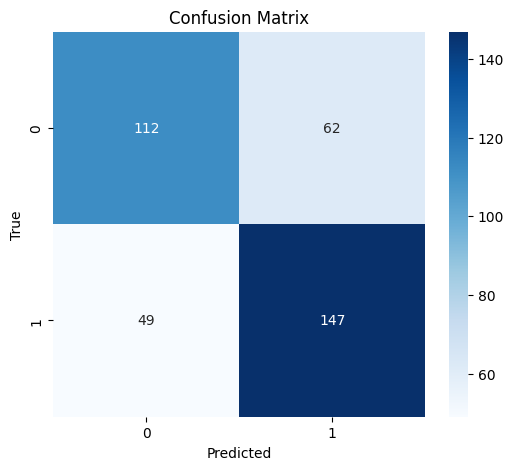

In [33]:

def evaluate_model(model, test_loader, threshold=0.55):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for input_ids, att_mask, user_feat, labels in test_loader:
            input_ids, att_mask = input_ids.to(device), att_mask.to(device)
            user_feat, labels = user_feat.to(device), labels.to(device)
            outputs = model(input_ids, att_mask, user_feat)
            preds = predict_with_threshold(outputs, threshold=threshold)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # --- Métricas globales ---
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)

    print(f"\n--- Métricas Totales (binaria) ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    # --- Matriz de confusión ---
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

# --- EJECUTAR ---
model = train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, config.epochs, patience=2)
evaluate_model(model, test_loader, threshold=0.55)